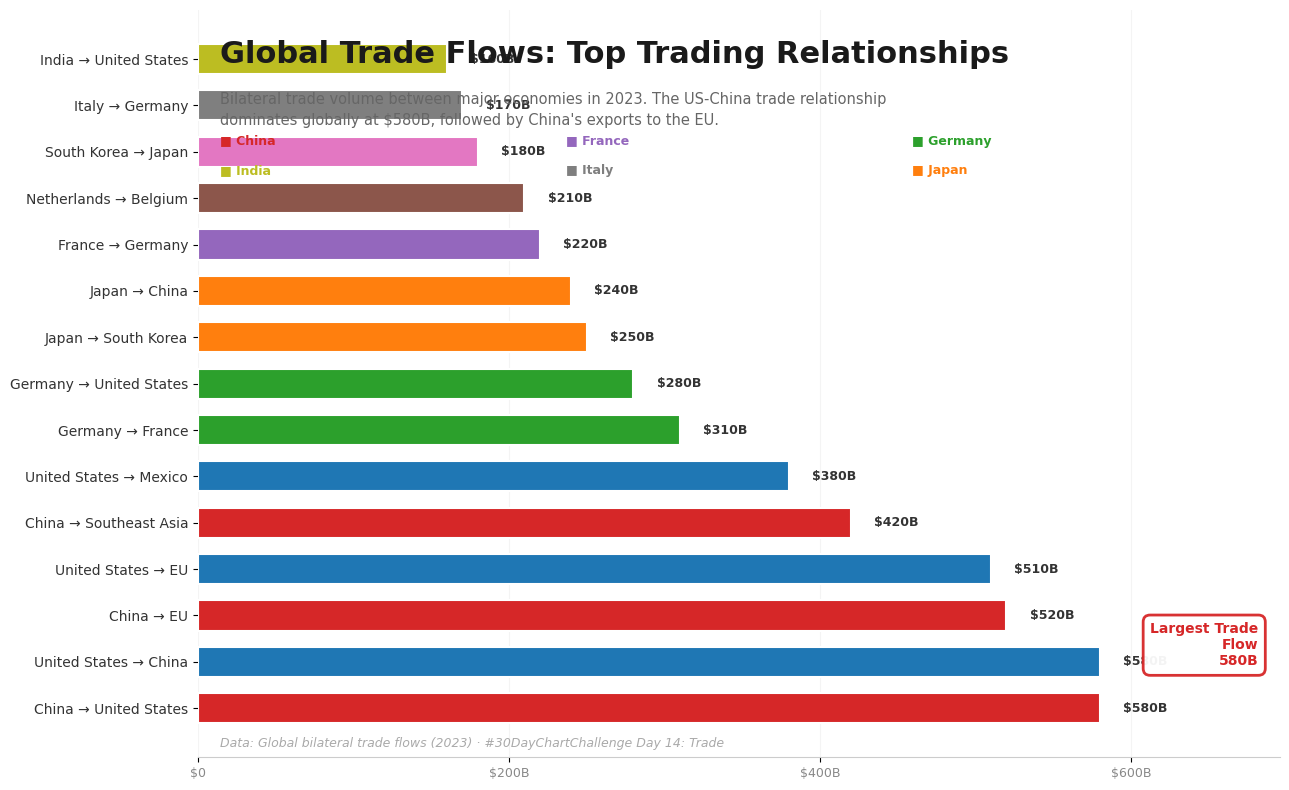

In [1]:
"""
#30DayChartChallenge — Day 14: Trade
"Global Trade Flows: Top Trading Relationships" — international commerce
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Top bilateral trade relationships by volume (2023)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Top bilateral trade flows (Billions USD)
# ---------------------------------------------------------------------------
data = {
    "Exporter": [
        "China", "China", "China", "United States", "United States", "United States",
        "Germany", "Germany", "Japan", "Japan",
        "France", "Netherlands", "South Korea", "Italy", "India"
    ],
    "Importer": [
        "United States", "EU", "Southeast Asia", "China", "EU", "Mexico",
        "France", "United States", "South Korea", "China",
        "Germany", "Belgium", "Japan", "Germany", "United States"
    ],
    "Trade_Volume": [
        580, 520, 420, 580, 510, 380,
        310, 280, 250, 240,
        220, 210, 180, 170, 160
    ]
}

df = pd.DataFrame(data)
df = df.sort_values("Trade_Volume", ascending=False)

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Color palette for exporters
exporter_colors = {
    "China": "#d62728",
    "United States": "#1f77b4",
    "Germany": "#2ca02c",
    "Japan": "#ff7f0e",
    "France": "#9467bd",
    "Netherlands": "#8c564b",
    "South Korea": "#e377c2",
    "Italy": "#7f7f7f",
    "India": "#bcbd22"
}

# Create paired country labels
df["Country_Pair"] = df["Exporter"] + " → " + df["Importer"]

# Horizontal bar chart
colors = [exporter_colors.get(exp, "#999999") for exp in df["Exporter"]]

bars = ax.barh(range(len(df)), df["Trade_Volume"], height=0.65, 
               color=colors, edgecolor="white", linewidth=1.5, zorder=3)

# Add value labels
for i, (idx, row) in enumerate(df.iterrows()):
    ax.text(row["Trade_Volume"] + 15, i, f"${row['Trade_Volume']:.0f}B",
            fontsize=9, fontweight="600", color="#333333", va="center")

# Y-axis labels (country pairs)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["Country_Pair"], fontsize=10, fontweight="500", color="#333333")

# Minimal styling
ax.set_xlim(0, df["Trade_Volume"].max() * 1.2)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.xaxis.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.set_xticks([0, 200, 400, 600])
ax.set_xticklabels(["$0", "$200B", "$400B", "$600B"], fontsize=9, color="#888888")

# Title & subtitle
ax.text(0.02, 0.96, "Global Trade Flows: Top Trading Relationships",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.89,
        "Bilateral trade volume between major economies in 2023. The US-China trade relationship\n"
        "dominates globally at $580B, followed by China's exports to the EU.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Legend
legend_x = 0.02
legend_y = 0.82
for i, (country, color) in enumerate(sorted(exporter_colors.items())[:6]):
    ax.text(legend_x + (i % 3) * 0.32, legend_y - (i // 3) * 0.04, f"■ {country}",
            fontsize=9, color=color, transform=ax.transAxes, fontweight="600")

# Highlight top trade
top_trade = df.iloc[0]
ax.text(0.98, 0.15, f"Largest Trade\nFlow\n{top_trade['Trade_Volume']:.0f}B",
        fontsize=10, fontweight="bold", color="#d62728", transform=ax.transAxes, 
        ha="right", va="center", bbox=dict(boxstyle="round,pad=0.5",
        facecolor="#fff", edgecolor="#d62728", linewidth=2, alpha=0.95))

# Source
ax.text(0.02, 0.01,
        "Data: Global bilateral trade flows (2023) · #30DayChartChallenge Day 14: Trade",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day14_trade.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()